In [1]:
#import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import functions 
import pandas as pd
from shapely.geometry import Point
from shapely import wkt
import geopandas as gpd
import mapclassify
#load datasets
raw_zwn = pd.read_csv("../data/raw/zwn_meldungen.csv")
raw_popsize = pd.read_csv("../data/raw/populationsize_zh.csv")
raw_quartiere = pd.read_csv("../data/raw/quartiere_zürich.csv")


#select needed columns
processed_zwn = raw_zwn[["service_name","requested_datetime","e","n","status","updated_datetime"]]
processed_quartiere = raw_quartiere[["qname","geometry"]]
pop_size = raw_popsize[["QuarLang","AnzBestWir","StichtagDatJahr"]]


#define new column names
new_names = {
"service_name":"category",
"e":"East",
"n":"North",
"requested_datetime":"report_time",
"updated_datetime":"resolved_time",
    }
processed_zwn= processed_zwn.rename(columns=new_names)

new_names1 = {
"qname":"Quartier",
    "geometry": "Geometry"
}
processed_quartiere= processed_quartiere.rename(columns=new_names1)

new_names_2 = {
"QuarLang":"Quartier",
"AnzBestWir":"PopSize",
}
pop_size= pop_size.rename(columns=new_names_2)

# Check missing values

#-------------------------------------------------------------------------------------------------------------------------
# Prepare processed_zwn dataset
#-------------------------------------------------------------------------------------------------------------------------

# convert datatype of "report_time" and "resolved_time" to datetime64
processed_zwn["report_time"] = pd.to_datetime(processed_zwn["report_time"], format ="%Y-%m-%dT%H:%M:%S")
processed_zwn["resolved_time"] = pd.to_datetime(processed_zwn["resolved_time"], format ="%Y-%m-%dT%H:%M:%S")

# create GeoDataFrame using the East and North coordinates as point geometry
processed_zwn = gpd.GeoDataFrame(processed_zwn,geometry=gpd.points_from_xy(processed_zwn["East"], processed_zwn["North"])
)
# select useful columns (without East and North)
#processed_zwn= processed_zwn[["category","report_time","geometry","status","resolved_time"]]

#define CRS (CH1903+ / LV95)
processed_zwn = processed_zwn.set_crs(epsg=2056)

#-------------------------------------------------------------------------------------------------------------------------
# Prepare processed_quartiere dataset
#-------------------------------------------------------------------------------------------------------------------------

# Convert geometry column from string format into geometry objects
processed_quartiere["Geometry"] = processed_quartiere["Geometry"].apply(wkt.loads)

#define "Geometry" column as spatial geometry in a GeoDataFrame
processed_quartiere = gpd.GeoDataFrame(
    processed_quartiere,
    geometry="Geometry")

#define missing CRS (CH1903+ / LV95)
processed_quartiere = processed_quartiere.set_crs(epsg=2056)


#-------------------------------------------------------------------------------------------------------------------------
# Prepare pop_size dataset
#-------------------------------------------------------------------------------------------------------------------------

# choose year 2025
pop_size= pop_size[raw_popsize["StichtagDatJahr"]	== 2025]

#-------------------------------------------------------------------------------------------------------------------------
#perform spatial join, gehöhrt nicht mehr zu Data Cleaning !!
#-------------------------------------------------------------------------------------------------------------------------
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="intersects")



C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


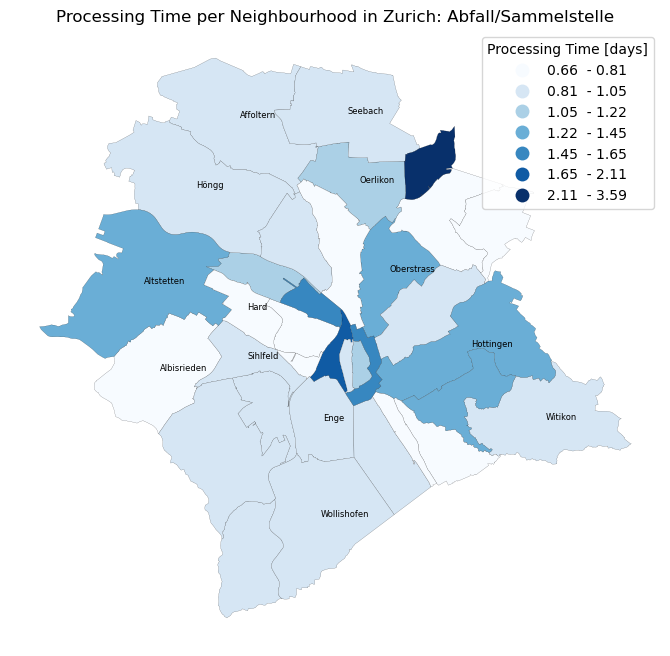

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


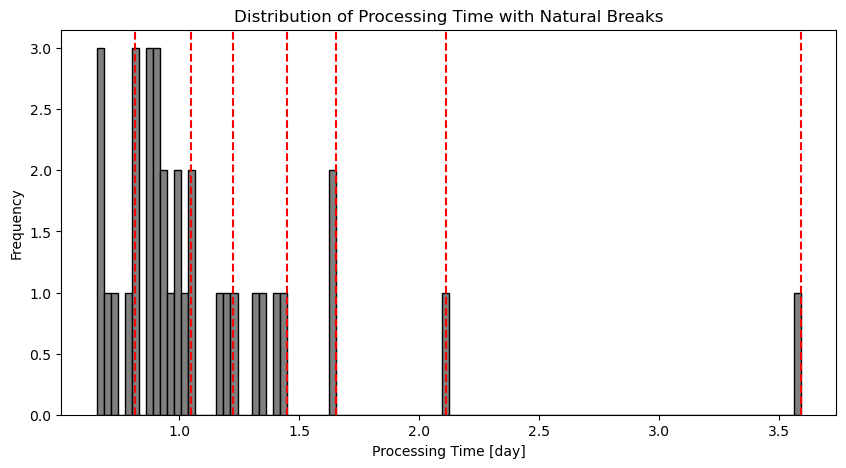

,Quartier,n
0,Affoltern,738
1,Albisrieden,620
2,Alt-Wiedikon,1241
3,Altstetten,1338
4,City,414
5,Enge,667
6,Escher Wyss,340
7,Fluntern,380
8,Friesenberg,321
9,Gewerbeschule,787


In [3]:
# Data Analysis: filter completed reports and calculate mean processing time
#----------------------------------------------------------------------------

zwn_filtred= zwn_with_quartiere[zwn_with_quartiere["status"] =="fixed - council"]
filter_category= zwn_filtred[zwn_filtred["category"]=="Abfall/Sammelstelle"]
filter_category["processing_time"] =  (filter_category["resolved_time"]- filter_category["report_time"])
counts = filter_category.groupby("Quartier").size().reset_index(name="n")
#valid_quartiere = counts[counts["n"] >= 10]
#filter_category = filter_category.merge(valid_quartiere, on="Quartier",how="inner")
mean = filter_category.groupby(["Quartier"])["processing_time"].mean().reset_index()
mean["processing_time_float"]= mean["processing_time"].dt.total_seconds()/86400
map_df = processed_quartiere.merge(mean, on="Quartier",how="left")










#--------------------------------------------------------------------------------
# Create Map
#--------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 

map_df.plot(column="processing_time_float",
            scheme = "naturalbreaks",
            k = 7,
            edgecolor = "black",
            legend=True,
            linewidth = 0.1,
            cmap="Blues",
            ax=ax, #draw the axes on the axes we creaed
            legend_kwds={
                "title": "Processing Time [days]",})
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
ax.set_title("Processing Time per Neighbourhood in Zurich: Abfall/Sammelstelle")
ax.axis("off")

# add neighbourhood labels
selected_quartiere =map_df[map_df["Quartier"].isin(["Affoltern","Seebach","Oerlikon","Höngg","Altstetten","Albisrieden","Enge","Wollishofen","Witikon","Hottingen","Sihlfeld","Hard","Oberstrass"])]

for i in range(len(selected_quartiere)):

    x = selected_quartiere.iloc[i]["Geometry"].centroid.x
    y = selected_quartiere.iloc[i]["Geometry"].centroid.y
    name = selected_quartiere.iloc[i]["Quartier"]

    ax.text(x, y, name, fontsize=6)

plt.show()

#--------------------------------------------------------------------------------------------------------------------------------------------------------------
# Create histogram
#----------------------------------------------------------------------------------------------------------------------------------------------------------
import mapclassify

classifier = mapclassify.NaturalBreaks(map_df["processing_time_float"],k=7)
breaks = classifier.bins

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(map_df["processing_time_float"], bins=100, color= "grey",edgecolor="black")

for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Processing Time with Natural Breaks")
plt.xlabel("Processing Time [day]")
plt.ylabel("Frequency")
plt.show()

test = filter_category[filter_category["Quartier"]=="Saatlen"]
counts